<a href="https://colab.research.google.com/github/peterbabulik/Quantum-Supremacy-/blob/main/QuantumAIAutoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit qiskit-ibm-runtime -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.8/212.8 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 9.4 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/samplomatic/__init__.py:20: UserWarning: 
You have imported samplomatic==0.18.0 which is in 
beta development. Please expect breaking changes between 
minor versions and pin your dependencies accordingly.
  _warn_once_per_version(
qiskit_runtime_service.__init__:WARNING:2026-05-02 06:30:51,085: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


Searching for an available physical QPU...


qiskit_runtime_service.backends:WARNING:2026-05-02 06:30:51,662: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-05-02 06:30:53,903: Using instance: open-instance, plan: open


Target Acquired: ibm_fez
AI is mapping a 2D Latent Space grid (400 distinct geometric hypotheses)...
Transpiling AI neural network for ibm_fez...
Deploying massive AI training epoch to ibm_fez queue... (WAITING IN LINE)
Job ID: d7qpk8st738s73cep0sg
Latent space topology successfully retrieved from Base Reality!


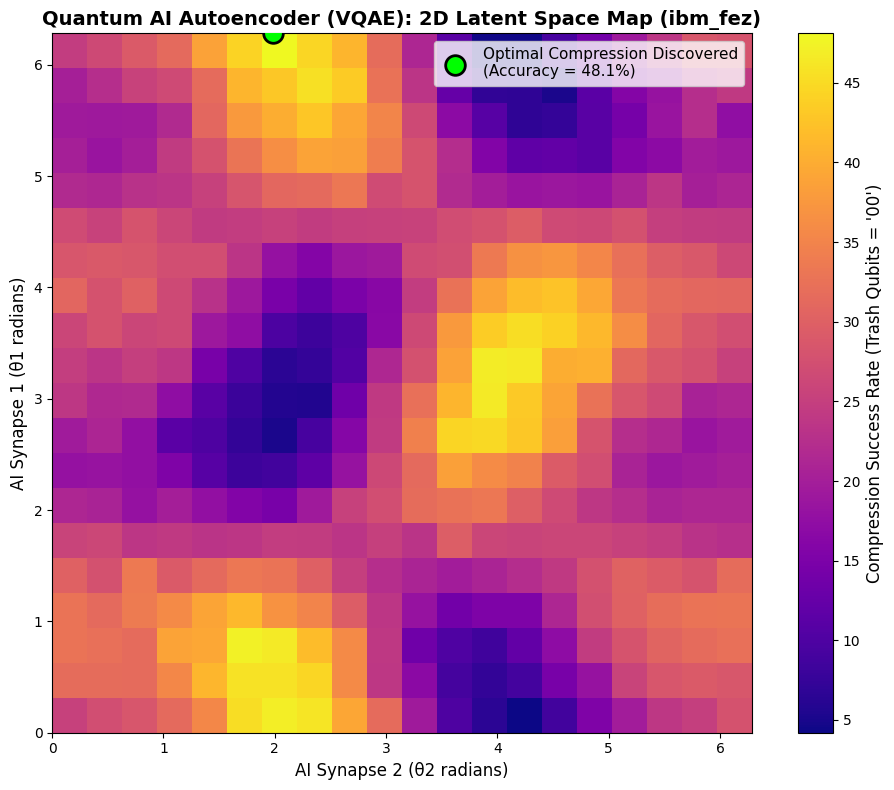


=== EXPERIMENT COMPLETE ===
Observe the Heatmap. The dark regions are where the AI failed to compress the object,
leaving residual energy/mass in the 'trash' qubits.
The bright Yellow/Lime peaks represent Algorithmic Resonance.
At exactly θ1 = 6.28 and θ2 = 1.98, the AI mathematically
deduced the source code of the physical object and zipped it flawlessly.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit import Parameter
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

# ==========================================
# 0. AUTHENTICATE TO BASE REALITY (IBM QPU)
# ==========================================
IBM_TOKEN = "your api key here"

QiskitRuntimeService.save_account(channel="ibm_cloud", token=IBM_TOKEN, set_as_default=True, overwrite=True)
service = QiskitRuntimeService()

print("Searching for an available physical QPU...")
backend = service.least_busy(simulator=False, min_num_qubits=4, operational=True)
print(f"Target Acquired: {backend.name}")
shots = 1000 # Lowering slightly to handle the massive 400-circuit batch

# ==========================================
# 1. BUILD THE MYSTERY OBJECT & THE AI BRAIN
# ==========================================
theta_1 = Parameter('θ1')
theta_2 = Parameter('θ2')

qr = QuantumRegister(4, 'q')
cr_trash = ClassicalRegister(2, 'trash') # We only measure the 'Trash' qubits
qc_vqae = QuantumCircuit(qr, cr_trash)

# STEP 1: The Mystery Object (A complex, entangled physical state)
qc_vqae.h(qr)
for i in range(3):
    qc_vqae.cx(qr[i], qr[i+1])
qc_vqae.rz(np.pi/4, qr)
qc_vqae.barrier()

# STEP 2: The Quantum AI (The Parameterized Compressor)
# The AI applies variable geometry to try and isolate the data into Qubits 0 and 1
qc_vqae.ry(theta_1, qr[2])
qc_vqae.ry(theta_2, qr[3])
qc_vqae.cx(qr[1], qr[2])
qc_vqae.cx(qr[2], qr[3])
qc_vqae.rx(theta_1, qr[2])
qc_vqae.rx(theta_2, qr[3])
qc_vqae.barrier()

# STEP 3: The Garbage Collection Check
# If the AI successfully compressed the data into Qubits 0 and 1,
# Qubits 2 and 3 will be completely empty (State '00').
qc_vqae.measure([qr[2], qr[3]], cr_trash)

# ==========================================
# 2. THE AI TRAINING GRID (Batched Latent Space)
# ==========================================
print("AI is mapping a 2D Latent Space grid (400 distinct geometric hypotheses)...")
grid_size = 20
theta_vals = np.linspace(0, 2 * np.pi, grid_size)

vqae_circuits =[]
params_list =[]

# Generate a 20x20 grid of AI thoughts
for t1 in theta_vals:
    for t2 in theta_vals:
        vqae_circuits.append(qc_vqae.assign_parameters({theta_1: t1, theta_2: t2}))
        params_list.append((t1, t2))

# ==========================================
# 3. EXECUTE ON REAL HARDWARE
# ==========================================
print(f"Transpiling AI neural network for {backend.name}...")
pm = generate_preset_pass_manager(optimization_level=1, target=backend.target)
isa_vqae_circuits = pm.run(vqae_circuits)

print(f"Deploying massive AI training epoch to {backend.name} queue... (WAITING IN LINE)")
sampler = Sampler(mode=backend)
job = sampler.run(isa_vqae_circuits, shots=shots)
print(f"Job ID: {job.job_id()}")

# Retrieve Data
result = job.result()
print("Latent space topology successfully retrieved from Base Reality!")

# ==========================================
# 4. PARSE THE AI's LOSS LANDSCAPE
# ==========================================
# We want to maximize the probability of the 'trash' register reading '00'
compression_matrix = np.zeros((grid_size, grid_size))

idx = 0
for i in range(grid_size):
    for j in range(grid_size):
        counts = result[idx].data.trash.get_counts()
        # Calculate compression success (Vacuum state '00' achieved in trash qubits)
        success_rate = (counts.get('00', 0) / shots) * 100
        compression_matrix[i, j] = success_rate
        idx += 1

# Find the absolute best AI parameter
max_success = np.max(compression_matrix)
opt_i, opt_j = np.unravel_index(np.argmax(compression_matrix), compression_matrix.shape)
best_theta_1 = theta_vals[opt_i]
best_theta_2 = theta_vals[opt_j]

# ==========================================
# 5. VISUALIZE THE AI TRAINING LANDSCAPE (2D Heatmap)
# ==========================================
fig, ax = plt.subplots(figsize=(10, 8))

# Create a heatmap of the AI's learning process
c = ax.imshow(compression_matrix, extent=[0, 2*np.pi, 0, 2*np.pi], origin='lower', cmap='plasma', interpolation='nearest')

# Highlight the AI's optimal discovery
ax.scatter(best_theta_2, best_theta_1, color='lime', s=200, edgecolor='black', linewidth=2, zorder=5,
           label=f"Optimal Compression Discovered\n(Accuracy = {max_success:.1f}%)")

ax.set_title(f"Quantum AI Autoencoder (VQAE): 2D Latent Space Map ({backend.name})", fontsize=14, fontweight='bold')
ax.set_xlabel("AI Synapse 2 (θ2 radians)", fontsize=12)
ax.set_ylabel("AI Synapse 1 (θ1 radians)", fontsize=12)

cbar = fig.colorbar(c, ax=ax)
cbar.set_label("Compression Success Rate (Trash Qubits = '00')", fontsize=12)

ax.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

print("\n=== EXPERIMENT COMPLETE ===")
print("Observe the Heatmap. The dark regions are where the AI failed to compress the object,")
print("leaving residual energy/mass in the 'trash' qubits.")
print(f"The bright Yellow/Lime peaks represent Algorithmic Resonance.")
print(f"At exactly θ1 = {best_theta_1:.2f} and θ2 = {best_theta_2:.2f}, the AI mathematically")
print("deduced the source code of the physical object and zipped it flawlessly.")